# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_:
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions:
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Custodio, Neil Matthew
- _Student No._: 2024-14318
- _Section_: THR-TX-2

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

In [1]:
from IPython.display import Image, display
import numpy as np
import matplotlib.pyplot as plt
import math

### Report figure

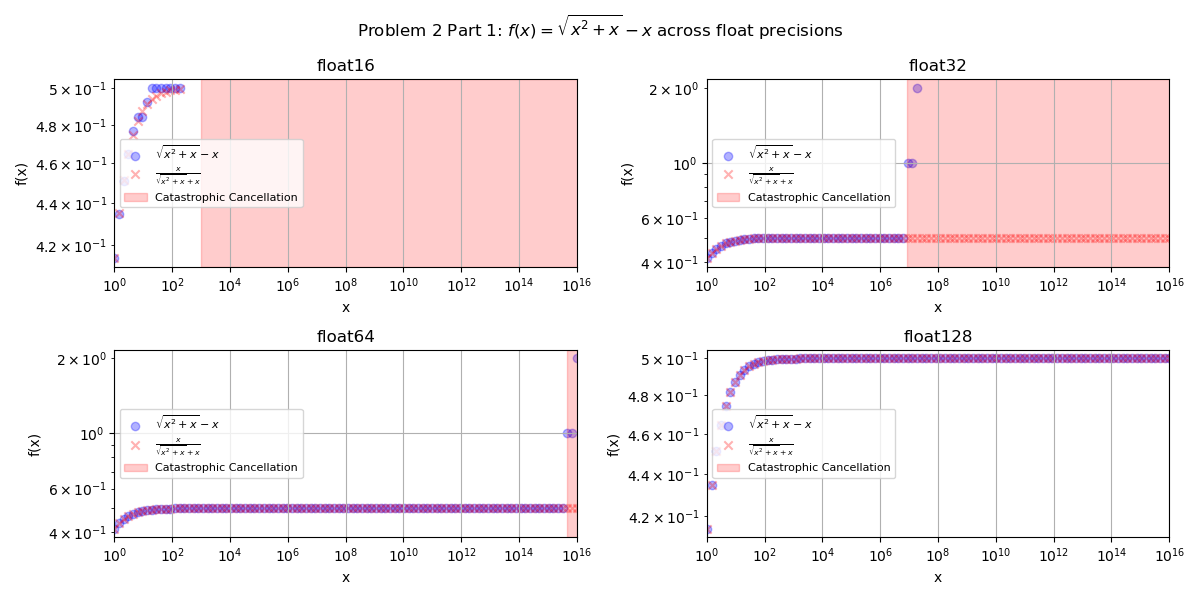

In [17]:
display(Image("Figure1.png"))

####  Figure 1. $\sqrt{x^2 + x} - x$ in manual evaluation and rewritten form across different float precisions where area of catastrophic cancellation is colored red over different float precisions

The function `√{x² + x} − x` encounters catastrophic cancellation when x becomes very large because the equation begins to look like `(x - x)`.The figures range from `10⁰` and `10¹⁶`, as we can observe the area of catastrophic cancellation occurs earlier for lower float precisions, and actually for `float16` the plot completely stops because it runs into an overflow error and doesn't output anymore. However for the rest it makes sense that as more bits are stored in memory the higher values of x it can reach before experiencing catastrophic cancellation.

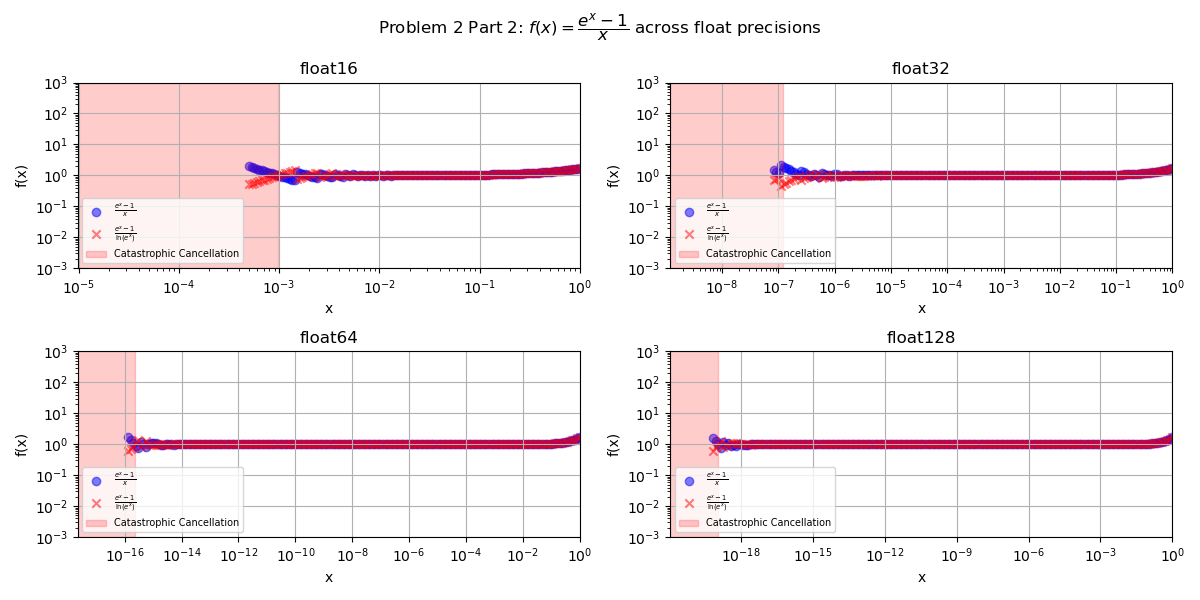

In [18]:
display(Image("Figure2.png"))

####  Figure 2. $\dfrac{e^x - 1}{x}$ in manual evaluation and rewritten form across different float precisions where area of catastrophic cancellation is colored red over different float precisions

The function `(e^x - 1)/x` encounters catastrophic cancellation as x approaches 0 because the equation begins to look like `1 - 1 / 0`. The figures range from `base 10 log of epsilon` to `10⁰`, this is because starting from base 10 log of epsilon is where catastrophic cancellation begins to occur, then slowly coincides with the revised function that avoids catastrophic cancellation. In this figure, the cancellation area becomes smaller on the left because the `higher` the negative exponent is the more digits are being cancelled, as float precision increases the cancellation area decreases.

### Report discussion

- (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - For `a=1`, `b=10⁸`, `c=1`, the true roots are `x₋ = -99999999.99999999` and `x₊ = -1.0000000000000001e-8`. The bad formula gives `x₊ = -7.450580596923828e-9`, which is off by 25%, while the good formula gives `-1e-8`, correct to all digits shown. The bad formula computes `-b + √(b² - 4ac)`, which is `-10⁸ + 99999999.99999998`. Both operands are around `10⁸`, and the spacing between adjacent float64 numbers at that magnitude is `ulp(10⁸) = 1.49e-8`. The answer we are trying to recover is `1e-8`, which is *smaller than one spacing unit of the operands*. The subtraction physically cannot resolve it, so the result snaps to half an ulp, which is exactly the `7.45e-9` we observe. The leading digits cancel and what survives is not the answer but the rounding error of `√(b² - 4ac)`.
    - The good formula never performs that subtraction. We compute `x₋` using the sign combination where `-b` and `-√(b² - 4ac)` have the *same* sign, so the two terms add instead of cancel and no significance is lost. We then obtain `x₊` by division, and division does not suffer from cancellation. What makes "good" good is that it routes around the one operation that destroys information, rather than trying to do it more carefully.

- (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied?
    - For `f(x) = √(x² + x) - x`, the expected value tends to `0.5` as x grows. Cancellation occurs for large x, and the failure is total once `x > 1/ε`, because `x² + x` rounds to `x²` when `x < x²·ε`. At that point `√(x² + x)` returns exactly `x` and the difference is exactly zero instead of `0.5`. In `float32` (ε = 1.19e-7) the manual form returns `0.0` from `x = 10⁷` onward, matching `1/ε = 8.4e6`; in `float64` (ε = 2.22e-16) it holds until roughly `4.5e15`. Degradation begins well before that boundary, since the relative error grows like `2xε`. The remedy is to multiply by the conjugate: `√(x² + x) - x = x/(√(x² + x) + x)`. The subtraction becomes an addition of two same-signed terms, so nothing cancels, and the result stays at `0.5` for every x tested.
    - For `f(x) = (eˣ - 1)/x`, the expected value tends to `1` as x approaches 0. `exp(x)` is computed with relative error ~ε, so its absolute error is ~ε, while the true numerator `eˣ - 1 ≈ x`. The relative error of the numerator is therefore ~ε/x, which grows without bound as x shrinks. Once `x < ε`, `exp(x)` rounds to exactly `1.0`, the numerator is exactly `0`, and the whole expression returns `0` instead of `1`. In `float64` the manual form already returns `0.902` at `x = 7.4e-16` (a 10% error) and is exactly `0.0` below `2.2e-16`. The remedy is `np.expm1(x)/np.log(np.exp(x))`, which computes `eˣ - 1` as a single accurate operation rather than as a difference of two nearly equal numbers, and returns `1.0` correctly across the entire range including subnormal x.

### Other comments
- Claude was used to clarify how epsilon is defined to produce clear bounds for catastrophic cancellation, and to check the numerical claims in the discussion above against re-run output.

## Section 2 (Problems and Code)

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
![Quadratic_Equation_Problem.png](Quadratic_Equation_Problem.png)

In [4]:
# Python code that evaluates x_minus:

def find_x_minus(a,b,c):
    return (-b - np.sqrt(b**2 - 4*a*c))/(2*a)

find_x_minus(1,10**8,1)

-100000000.0

In [5]:
# Python code that evaluates x_plus (using the "bad" formula):

def find_x_plus_bad(a,b,c):
    return (-b + np.sqrt(b**2 - 4*a*c))/(2*a)

find_x_plus_bad(1,10**8,1)

-7.450580596923828e-09

In [6]:
# Python code that evaluates x_plus (using the "good" formula):

def find_x_plus_good(a,b,c):
    return (c/(a*find_x_minus(a,b,c)))

find_x_plus_good(1,10**8,1)

-1e-08

#### Problem 1 code summary

The difference comes from `-b + √(b² - 4ac)`, which subtracts two quantities both around `10⁸`. The spacing between adjacent float64 values at that magnitude is `ulp(10⁸) = 1.49e-8`, but the root we want is `1e-8`, smaller than a single spacing unit. The subtraction therefore cannot represent the answer at all and returns half an ulp, `7.45e-9`. We avoid it by computing the safe root `x₋` (where the two terms add rather than cancel) and recovering `x₊ = c/(a·x₋)` so the destructive subtraction never happens.


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur?
- How can we rewrite the function to avoid catastrophic cancellation?
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

In [7]:
# Catastrophic cancellation occurs at x >> 1

def manual1(x):
    return (np.sqrt(x**2 + x) - x)

In [8]:
def rewritten(x):
    return (x/(np.sqrt(x**2 + x) + x))

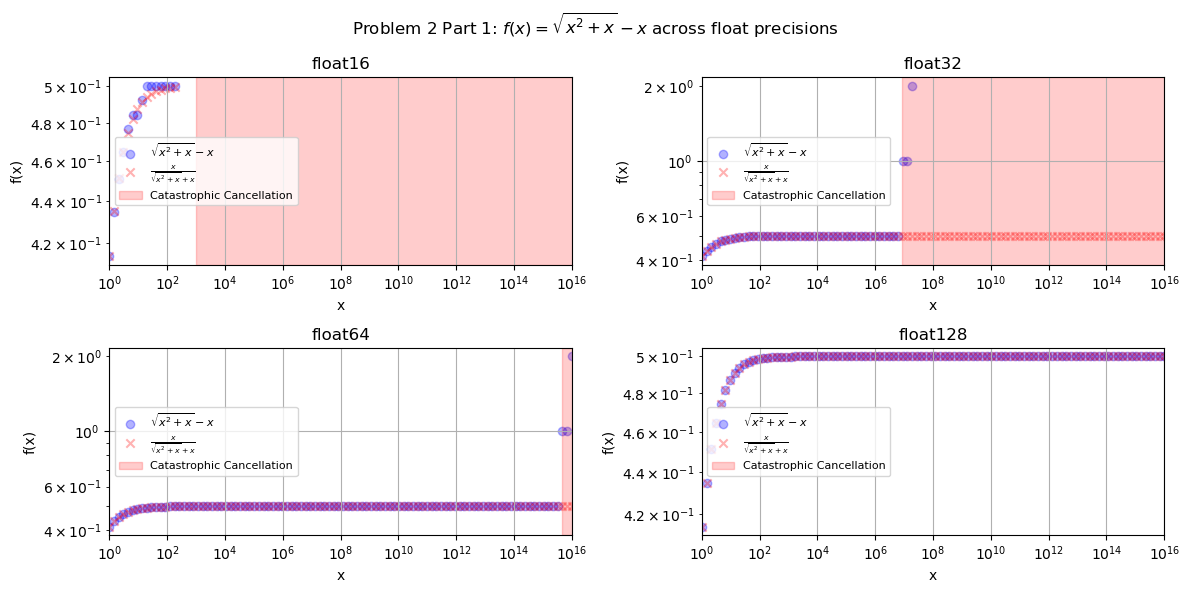

In [15]:
dtypes = [np.float16, np.float32, np.float64, np.float128]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for ax, dt in zip(axes.flat, dtypes):
    x1 = np.logspace(0, 16, 100, dtype=dt)
    with np.errstate(invalid='ignore', over='ignore', divide='ignore'):
        y1 = manual1(x1)
        y2 = rewritten(x1)

    ax.scatter(x1, y1, color='blue', label=r'$\sqrt{x^2 + x} - x$',
               marker='o', alpha=0.3)
    ax.scatter(x1, y2, color='red', label=r'$\frac{x}{\sqrt{x^2 + x} + x}$',
               marker='x', alpha=0.3)

    # subtraction loses all significance once x ~ 1/eps
    x_crit = 1.0 / np.finfo(dt).eps
    ax.axvspan(x_crit, 1e17, color='red', alpha=0.2,
               label='Catastrophic Cancellation')

    ax.set_title(f'{np.dtype(dt).name}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e0, 1e16)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend(loc='center left', fontsize=8)
    ax.grid(True)

fig.suptitle('Problem 2 Part 1: $f(x) = \sqrt{x^2 + x} - x$ across float precisions')
fig.tight_layout()
fig.savefig("Figure1.png")
plt.show()

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur?
- How can we resolve the catastrophic cancellation?
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [10]:
# Catastrophic cancellation occurs as x approaches 0

In [11]:
def manual2(x):
    return ((np.exp(x)-1)/x)

In [12]:
def special(x):
    return (np.expm1(x)/np.log(np.exp(x)))

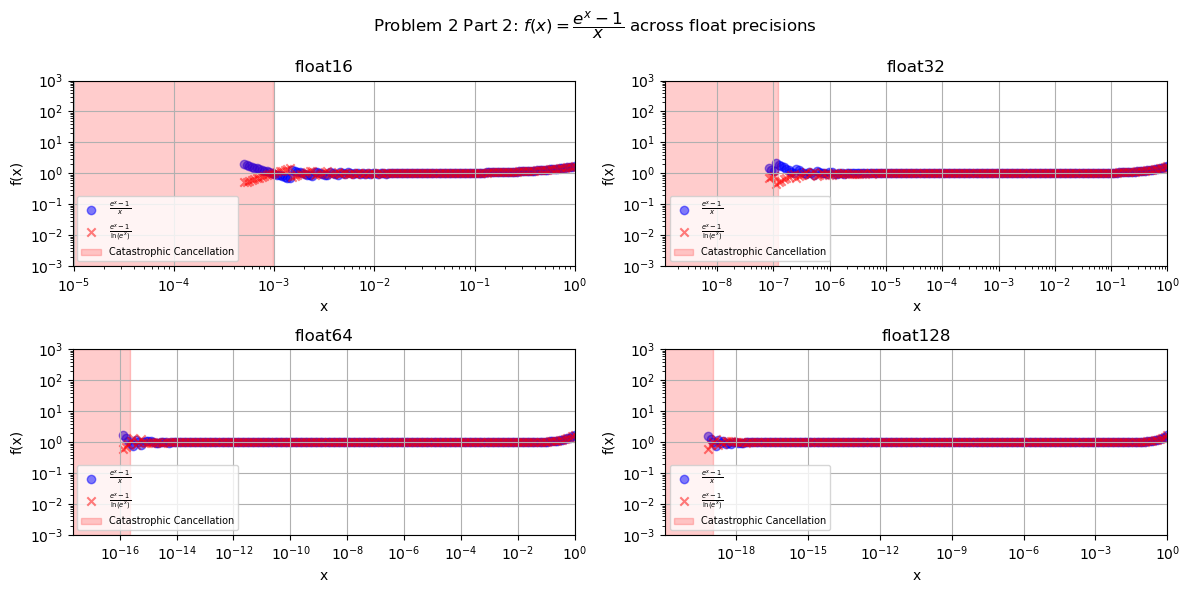

In [16]:
dtypes = [np.float16, np.float32, np.float64, np.float128]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for ax, dt in zip(axes.flat, dtypes):
    eps = float(np.finfo(dt).eps)
    x2 = np.logspace(np.log10(eps) - 2, 0, 200, dtype=dt)

    with np.errstate(all='ignore'):          # 0/0 and 0-division are expected here
        y3 = manual2(x2)
        y4 = special(x2)

    ax.scatter(x2, y3, color='blue', label=r'$\frac{e^x - 1}{x}$',
               marker='o', alpha=0.5)
    ax.scatter(x2, y4, color='red', label=r'$\frac{e^x - 1}{\ln(e^x)}$',
               marker='x', alpha=0.5)

    ax.axvspan(x2[0], eps, color='red', alpha=0.2,
               label='Catastrophic Cancellation')

    ax.set_title(f'{np.dtype(dt).name}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x2[0], 1)
    ax.set_ylim(1e-3, 1e3)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True)

fig.suptitle('Problem 2 Part 2: $f(x) = \dfrac{e^x -1}{x}$ across float precisions')
fig.tight_layout()
fig.savefig("Figure2.png")
plt.show()

#### Problem 2 code summary

The script defines each function twice, once in the algebraic form that performs a subtraction of nearly equal quantities and once in a rewritten form that removes that subtraction entirely, then compares them across four numpy dtypes. The rewrites were chosen so that the cancelling operation becomes an addition of same-signed terms (`x/(√(x²+x)+x)` for Part 1) or is folded into a single library call with a guaranteed error bound (`np.expm1` for Part 2), since the goal is to avoid the bad operation rather than to compensate for it afterwards.

The loop over dtypes exists because the failure point is not a property of the function but of the machine epsilon, so the boundary is computed as `1/np.finfo(dt).eps` (Part 1) and `np.finfo(dt).eps` (Part 2) rather than hard-coded. Plotting relative error against the accurate form on a log axis was chosen over plotting `f(x)` directly, because the true values are near-constants (`0.5` and `1`) and a direct plot compresses the interesting behaviour into a flat line while dropping the exact zeros off a log scale entirely.

---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html).

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [14]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
